# ASSIGNMENT — Dynamic Regression with Variants (Germany)


---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/ShamsaraE/time-series-medicine-biology-2026/blob/main/notebooks/04_ASSIGNMENT_DynamicRegression_Ridge_ElasticNet_RF.ipynb)
---


## Objective

You will compare:

1. **Baseline models**
2. **Ridge regression**
3. **ElasticNet regression**
4. **Random Forest**

You will:

- Use weekly data
- Apply nested cross-validation
- Compare MAE and RMSE
- Extract and interpret feature importance
- Write a short structured report

---

## Mathematical Model

We model:

z_t = log(1 + cases_t)

$
z_t =
\phi_1 z_{t-1}+\phi_2 z_{t-2}+\phi_3 z_{t-3}
+ \beta_V V_{t-2}
+ \beta_S S_t
+ \beta_{VS}(V_{t-2}\cdot C_t)
+ \sum_{k=1}^{K-1}\gamma_k \mathbb{1}\{C_t = c_k\}
+ \varepsilon_t.
$


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
np.random.seed(SEED)

## Step 1 — Load Weekly Dataset

Reuse the weekly dataset construction from the previous notebook.

Make sure you end up with:

- df_model
- X (features)
- y (target)

In [2]:
country = "Germany"

owid_url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
variant_url = "https://raw.githubusercontent.com/EU-ECDC/Respiratory_viruses_weekly_data/refs/heads/main/data/variants.csv"

In [3]:
# Your code here
df_daily = pd.read_csv(owid_url, parse_dates=["date"])

df_daily = df_daily[df_daily["location"] == country][[
    "date",
    "new_cases_smoothed",
    "stringency_index",
    "people_vaccinated_per_hundred"
]].dropna()

df_daily = df_daily[df_daily["date"] >= "2020-03-01"].sort_values("date").reset_index(drop=True)

vacc_start = df_daily.loc[df_daily["people_vaccinated_per_hundred"] > 0, "date"].min()
vacc_start

Timestamp('2020-12-27 00:00:00')

In [4]:
df_weekly = (
    df_daily
    .set_index("date")
    .resample("W-MON")
    .agg({
        "new_cases_smoothed": "mean",
        "people_vaccinated_per_hundred": "last",
        "stringency_index": "mean"
    })
    .dropna()
)

# Restrict to vaccination period
df_weekly = df_weekly.loc[df_weekly.index >= vacc_start].copy()

df_weekly.head(), df_weekly.tail()

(            new_cases_smoothed  people_vaccinated_per_hundred  \
 date                                                            
 2020-12-28        19832.570000                           0.05   
 2021-01-04        19184.610000                           0.42   
 2021-01-11        18485.201429                           0.90   
 2021-01-18        19701.695714                           1.52   
 2021-01-25        16035.737143                           2.02   
 
             stringency_index  
 date                          
 2020-12-28         82.410000  
 2021-01-04         82.410000  
 2021-01-11         84.658571  
 2021-01-18         83.330000  
 2021-01-25         83.330000  ,
             new_cases_smoothed  people_vaccinated_per_hundred  \
 date                                                            
 2022-12-05        24950.920000                          77.79   
 2022-12-12        27002.752857                          77.80   
 2022-12-19        29457.772857                

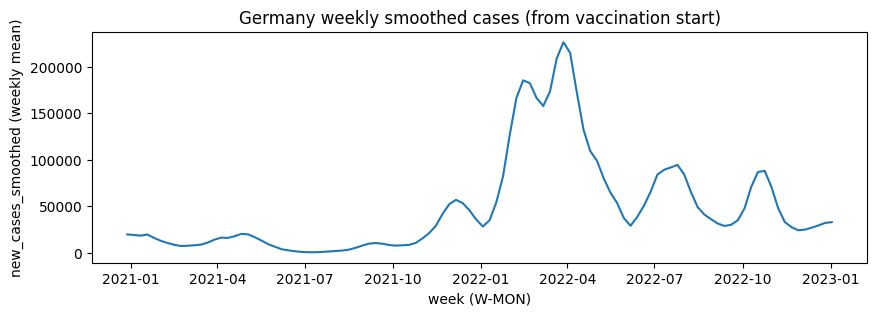

In [5]:
plt.figure(figsize=(10, 3))
plt.plot(df_weekly.index, df_weekly["new_cases_smoothed"])
plt.title("Germany weekly smoothed cases (from vaccination start)")
plt.xlabel("week (W-MON)")
plt.ylabel("new_cases_smoothed (weekly mean)")
plt.show()

In [6]:
var = pd.read_csv(variant_url)

# Filter Germany + SARS-CoV-2 + proportion + total age
var = var[
    (var["countryname"] == country) &
    (var["pathogen"] == "SARS-CoV-2") &
    (var["indicator"] == "proportion") &
    (var["age"] == "total")
].copy()

# ISO week -> Monday of that week
var["week_start"] = pd.to_datetime(var["yearweek"] + "-1", format="%G-W%V-%u", errors="coerce")
var = var.dropna(subset=["week_start"])

# Dominant lineage per week
dominant = var.loc[var.groupby("week_start")["value"].idxmax(), ["week_start", "variant"]]
dominant = dominant.sort_values("week_start").reset_index(drop=True)

dominant.head(), dominant.tail()

(  week_start    variant
 0 2021-06-21  B.1.617.2
 1 2021-06-28  B.1.617.2
 2 2021-07-05  B.1.617.2
 3 2021-07-12  B.1.617.2
 4 2021-07-19  B.1.617.2,
     week_start   variant
 237 2026-01-05  NB.1.8.1
 238 2026-01-12       XFG
 239 2026-01-19  NB.1.8.1
 240 2026-01-26  NB.1.8.1
 241 2026-02-02  NB.1.8.1)

In [7]:
df_weekly = df_weekly.reset_index().rename(columns={"date": "week_start"})
df_weekly = df_weekly.merge(dominant, on="week_start", how="left").sort_values("week_start")

# Forward-fill any missing weekly variants (rare; depends on reporting)
df_weekly["variant"] = df_weekly["variant"].ffill()

# If some early weeks still have missing (e.g., variant surveillance starts later),
# we can drop them for modeling to avoid leakage/ambiguity.
df_weekly = df_weekly.dropna(subset=["variant"]).reset_index(drop=True)

df_weekly.head(10)

,week_start,new_cases_smoothed,people_vaccinated_per_hundred,stringency_index,variant
0,2021-06-21,1732.245714,52.38,69.440000,B.1.617.2
1,2021-06-28,941.690000,55.34,69.440000,B.1.617.2
2,2021-07-05,674.917143,58.09,69.440000,B.1.617.2
3,2021-07-12,676.205714,59.91,69.440000,B.1.617.2
4,2021-07-19,943.081429,61.21,69.440000,B.1.617.2
5,2021-07-26,1446.062857,62.15,69.440000,B.1.617.2
6,2021-08-02,1923.958571,62.94,68.648571,B.1.617.2
7,2021-08-09,2417.470000,63.61,61.110000,B.1.617.2
8,2021-08-16,3393.244286,64.39,61.110000,B.1.617.2
9,2021-08-23,5299.775714,65.27,57.365714,B.1.617.2


In [8]:
# Sanity check: any remaining NaNs?
df_weekly.isna().sum()

,0
week_start,0
new_cases_smoothed,0
people_vaccinated_per_hundred,0
stringency_index,0
variant,0


In [9]:
# Target
df_weekly["z"] = np.log1p(df_weekly["new_cases_smoothed"])

# AR(3)
for lag in [1, 2, 3]:
    df_weekly[f"z_lag{lag}"] = df_weekly["z"].shift(lag)

# Vaccination lag
df_weekly["vacc_lag2"] = df_weekly["people_vaccinated_per_hundred"].shift(2)

# Variant one-hot encoding
variant_dummies = pd.get_dummies(df_weekly["variant"], prefix="var", drop_first=True)
df_weekly = pd.concat([df_weekly, variant_dummies], axis=1)

# Interaction terms
for col in variant_dummies.columns:
    df_weekly[f"{col}_x_vacc"] = df_weekly["vacc_lag2"] * df_weekly[col]

df_model = df_weekly.dropna().copy()

feature_cols = (
    ["z_lag1", "z_lag2", "z_lag3", "vacc_lag2"] +
    list(variant_dummies.columns) +
    [f"{col}_x_vacc" for col in variant_dummies.columns]
)

X = df_model[feature_cols]
y = df_model["z"]



In [10]:
df_model["variant"].value_counts()

,count
variant,
BA.5,30
B.1.617.2,24
BA.2,15
BA.1,8
BQ.1,1


In [11]:
df_model["variant"].unique()

array(['B.1.617.2', 'BA.1', 'BA.2', 'BA.5', 'BQ.1'], dtype=object)

In [12]:
X.head()

,z_lag1,z_lag2,z_lag3,vacc_lag2,var_BA.1,var_BA.2,var_BA.5,var_BQ.1,var_BA.1_x_vacc,var_BA.2_x_vacc,var_BA.5_x_vacc,var_BQ.1_x_vacc
3,6.516070,6.848737,7.457751,55.34,False,False,False,False,0.0,0.0,0.0,0.0
4,6.517975,6.516070,6.848737,58.09,False,False,False,False,0.0,0.0,0.0,0.0
5,6.850212,6.517975,6.516070,59.91,False,False,False,False,0.0,0.0,0.0,0.0
6,7.277291,6.850212,6.517975,61.21,False,False,False,False,0.0,0.0,0.0,0.0
7,7.562660,7.277291,6.850212,62.15,False,False,False,False,0.0,0.0,0.0,0.0


In [13]:
test_size = 52  # last 52 weeks = last year

y_train = y.iloc[:-test_size]
y_test  = y.iloc[-test_size:]

X_train = X.iloc[:-test_size]
X_test  = X.iloc[-test_size:]

## Step 2 — Baselines

Compute:
Baseline

In [14]:
# Your code here
# Seasonal baseline : use value from one week ago
y_test_orig = y_test.copy()
persistence_naive = y_test_orig.shift(1)
persistence_naive.iloc[0] = y_train.iloc[-1]


In [15]:
mae_p = mean_absolute_error(y_test, persistence_naive)
rmse_p = math.sqrt(mean_squared_error(y_test, persistence_naive))

print("Seasonal Naive MAE (log scale):", mae_p)
print("Seasonal Naive RMSE (log scale):", rmse_p)

Seasonal Naive MAE (log scale): 0.18310306277756877
Seasonal Naive RMSE (log scale): 0.2182588732008753


## Step 3 — Ridge Regression

In [16]:
# like before!
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {"ridge__alpha": np.logspace(-3, 3, 13)}

tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(pipe, param_grid=param_grid, cv=tscv)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_alpha = grid.best_params_["ridge__alpha"]

best_alpha

np.float64(0.001)

In [17]:
# In-sample fitted values (for quick visualization)
y_hat = best_model.predict(X_test)

mae_r = mean_absolute_error(y_test, y_hat)
rmse_r = math.sqrt(mean_squared_error(y_test, y_hat))

(mae_r, rmse_r)

(0.10406776328351598, 0.13377156331841653)

In [18]:
coefs = best_model.named_steps["ridge"].coef_

importance = (
    pd.DataFrame({"feature": feature_cols, "coef": coefs})
    .assign(abs_coef=lambda d: np.abs(d["coef"]))
    .sort_values("abs_coef", ascending=False)
    .reset_index(drop=True)
)

importance.head(25)

,feature,coef,abs_coef
0,z_lag1,2.756658,2.756658
1,z_lag2,-2.210477,2.210477
2,z_lag3,0.628889,0.628889
3,var_BA.1,-0.231685,0.231685
4,var_BA.1_x_vacc,0.205608,0.205608
5,vacc_lag2,0.079741,0.079741
6,var_BA.5,0.000000,0.000000
7,var_BA.2,0.000000,0.000000
8,var_BQ.1,0.000000,0.000000
9,var_BA.2_x_vacc,0.000000,0.000000


In [19]:
# Extract coefficients from trained Ridge model
coefs = best_model.named_steps["ridge"].coef_
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": coefs
})


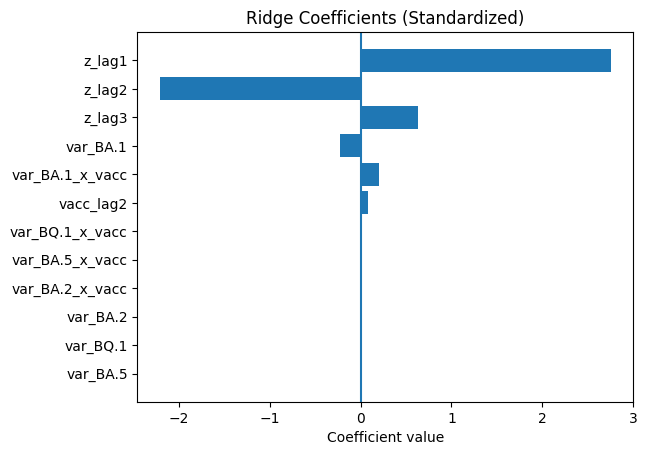

In [20]:
# Sort by absolute value
coef_plot = coef_df.copy()
coef_plot["abs_coef"] = np.abs(coef_plot["coef"])
coef_plot = coef_plot.sort_values("abs_coef", ascending=True)

plt.figure()
plt.barh(coef_plot["feature"], coef_plot["coef"])
plt.axvline(0)
plt.title("Ridge Coefficients (Standardized)")
plt.xlabel("Coefficient value")
plt.show()

## Step 4 — ElasticNet

ElasticNet combines L1 and L2:

- L1 performs feature selection
- L2 stabilizes estimates

In [21]:
# Your code here
model_elastic = Pipeline([("scaler", StandardScaler()), ("elastic", ElasticNet(alpha=0.1, l1_ratio=0.5))])
model_elastic.fit(X_train, y_train)
coef_elastic = model_elastic.named_steps["elastic"].coef_
importance_elastic = pd.Series(np.abs(coef_elastic), index=feature_cols).sort_values(ascending=False)

print(importance_elastic.head(25))

signed_importance_elastic = pd.Series(coef_elastic, index=feature_cols).sort_values(key=np.abs, ascending=False)
print(signed_importance_elastic.head(25))

z_lag1             0.762661
vacc_lag2          0.260510
z_lag2             0.149306
var_BA.1_x_vacc    0.018766
var_BA.1           0.017218
z_lag3             0.000000
var_BA.5           0.000000
var_BA.2           0.000000
var_BQ.1           0.000000
var_BA.2_x_vacc    0.000000
var_BA.5_x_vacc    0.000000
var_BQ.1_x_vacc    0.000000
dtype: float64
z_lag1             0.762661
vacc_lag2          0.260510
z_lag2             0.149306
var_BA.1_x_vacc   -0.018766
var_BA.1          -0.017218
z_lag3             0.000000
var_BA.5           0.000000
var_BA.2           0.000000
var_BQ.1           0.000000
var_BA.2_x_vacc    0.000000
var_BA.5_x_vacc    0.000000
var_BQ.1_x_vacc    0.000000
dtype: float64


In [31]:
param_grid_elastic = {"alpha": np.logspace(-4, 2, 20), "l1_ratio": np.linspace(0, 1, 11)}
grid_elastic = GridSearchCV(ElasticNet(), param_grid=param_grid_elastic, cv=tscv)
grid_elastic.fit(X_train, y_train)
best_model_elastic = grid_elastic.best_estimator_
importance_best_elastic = pd.Series(best_model_elastic.coef_, index=feature_cols).sort_values(key=np.abs, ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.330e-04, tolerance: 1.795e-04 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.660e-02, tolerance: 8.562e-04 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

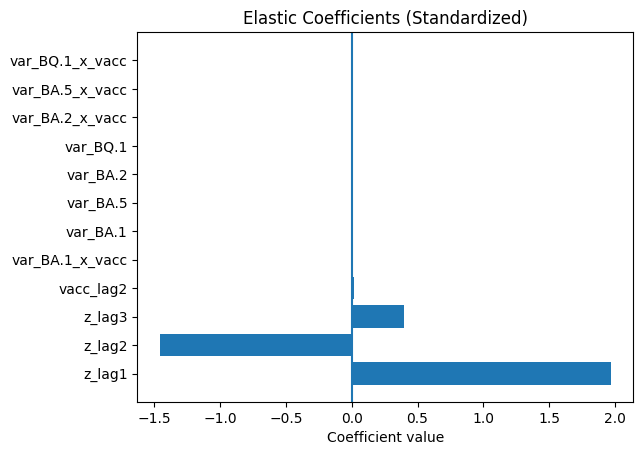

In [32]:
# already abs values
plt.figure()
plt.barh(importance_best_elastic.index, importance_best_elastic.values)
plt.axvline(0)
plt.title("Elastic Coefficients (Standardized)")
plt.xlabel("Coefficient value")
plt.show()

In [33]:
# In-sample fitted values (for quick visualization)
y_hat_elastic = best_model_elastic.predict(X_test)

mae_r_elastic = mean_absolute_error(y_test, y_hat_elastic)
rmse_r_elastic = math.sqrt(mean_squared_error(y_test, y_hat_elastic))

(mae_r_elastic, rmse_r_elastic)

(0.11078046133758851, 0.13898269412958095)

## Step 5 — Nonlinear Model (Random Forest)


In [34]:
# your code here
rf = RandomForestRegressor(n_estimators=300,
                           max_depth=3,
                           min_samples_split=2,
                           min_samples_leaf=3,
                           max_features='sqrt',
                           bootstrap=False, # to avoid random sampling
                           random_state=SEED)
rf.fit(X_train, y_train)
importance_rf = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importance_rf.head(25))

vacc_lag2          0.279668
z_lag1             0.261848
z_lag2             0.236618
z_lag3             0.221865
var_BA.1           0.000000
var_BA.2           0.000000
var_BA.5           0.000000
var_BQ.1           0.000000
var_BA.1_x_vacc    0.000000
var_BA.2_x_vacc    0.000000
var_BA.5_x_vacc    0.000000
var_BQ.1_x_vacc    0.000000
dtype: float64


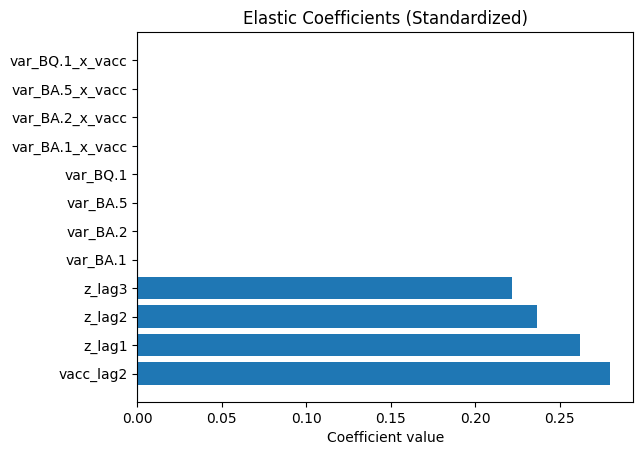

In [35]:
plt.figure()
plt.barh(importance_rf.index, importance_rf.values)
plt.axvline(0)
plt.title("RF Coefficients (Standardized)")
plt.xlabel("Coefficient value")
plt.show()

In [36]:
# In-sample fitted values (for quick visualization)
y_hat_rf = rf.predict(X_test)

mae_r_rf = mean_absolute_error(y_test, y_hat_rf)
rmse_r_rf = math.sqrt(mean_squared_error(y_test, y_hat_rf))

(mae_r_rf, rmse_r_rf)

(0.8798625968211353, 1.0839426413763409)

## Step 6 — Feature Importance

For:

- Ridge → standardized coefficients
- ElasticNet → coefficients (many may be zero)
- Random Forest → feature_importances_

In [28]:
# Your code here
# see above

## Step 7 — Model Comparison (metrics)

In [29]:
# Your code here